# ¡Hola Miguel! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Buen trabajo Miguel! Has completado correctamente todo lo necesario del notebook, realizaste un gran trabajo aplicando los conocimientos de analítica necesarios, se nota que los manejas muy bien. No tengo comentarios de corrección, tu proyecto está aprobado. Felicitaciones por completar el notebook en la primera revisión, mucho éxito en el siguiente sprint!

Saludos!

</div>

----

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [31]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [32]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [33]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [34]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien con la exploración inicial de los datos, has utilizado `head()` e `info()` correctamente, estos dos métodos son esenciales en la exploración de los datos.



</div>

El dataset contiene 40,000 registros y 9 columnas.

No se observan valores ausentes en ninguna de las variables, por lo que no será necesario realizar procesos de imputación o eliminación de registros por valores nulos.

Las columnas converted y gasto tienen tipos de datos correctos para el análisis estadístico posterior:
- converted como variable binaria entera.
- gasto como variable numérica decimal.

La columna date se encuentra almacenada como tipo object, aunque representa fechas. Por ello, será necesario convertirla a formato datetime para facilitar futuros análisis temporales.

En general, el dataset presenta una estructura consistente y adecuada para continuar con el proceso de exploración y análisis del experimento A/B.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [35]:
df['user_id'].nunique()

40000

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien, con `nunique()` contamos correctamente los usuarios únicos del dataset.



</div>

 **Variable `date`**  
Explorar rango de fechas

In [36]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [37]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien con la exploración del rango temporal, el uso de `min()`  y `max()` para las fechas permite obtener los bordes del rango facilmente.



</div>

**Variable `gasto` (numérica)**

In [38]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [39]:
# Resumen estadístico de usuarios que se convirtieron
usuarios_convertidos = df[df['converted'] == 1]
usuarios_convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien con el uso de `describe()` para explorar el gasto, para variables numéricas es muy útil. Vemos importante realizar el análisis a nivel general y también seleccionando solamente los usuarios que convirtieron.



</div>

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [40]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


In [41]:
df['landing'].value_counts(normalize=True)

B    0.50045
A    0.49955
Name: landing, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho con la exploración de estas variables, bien con el uso de `value_counts()`.





</div>

La variable landing contiene únicamente las dos categorías esperadas del experimento: A y B.

No se identificaron valores inconsistentes, categorías mal escritas o registros inesperados dentro de esta variable.

Además, la distribución entre ambas versiones se encuentra prácticamente balanceada:
- Versión B: 50.045%
- Versión A: 49.955%

Esto es positivo para el experimento A/B, ya que reduce posibles sesgos y permite realizar comparaciones estadísticas más confiables entre ambos grupos.

In [42]:
# Gasto por versión
gasto_A = df[df['landing'] == 'A']['gasto']
gasto_B = df[df['landing'] == 'B']['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

In [43]:
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']

gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre las versiones A y B.
- **Hipótesis alternativa (H₁):** Sí existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre las versiones A y B.

In [44]:
# Aplicar prueba
stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)


# Visualizar resultados
print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")

Estadístico: -9.48101092267275
Valor p: 3.627602231521493e-21


In [45]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia estadísticamente significativa en el gasto promedio entre las versiones A y B.")
else:
    print("No se rechaza la hipótesis nula.")
    print("No existe evidencia suficiente para afirmar diferencias significativas entre ambas versiones.")

Se rechaza la hipótesis nula.
Existe una diferencia estadísticamente significativa en el gasto promedio entre las versiones A y B.


In [46]:
print(gasto_A.mean())
print(gasto_B.mean())

61.0865724522293
68.74536005009392


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Bien hecho, correcto el test aplicado. Recuerda que podrías utilizar el test de Levene para determinar si las varianzas son iguales o diferentes e incluir aquello en los parámetros de la función `ttest_ind`


</div>


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p obtenido es menor al nivel de significancia de 0.05.

**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre las versiones A y B de la landing page.

La versión B presenta un gasto promedio más alto en comparación con la versión A, lo que sugiere que los usuarios que convierten en la página B generan mayor valor económico para el negocio.

Esto podría indicar que la versión B tiene un diseño, estructura o experiencia de usuario más efectiva para incentivar compras de mayor valor.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa en la tasa de conversión entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre la página A y la página B.

In [47]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_usuarios = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", total_usuarios)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [48]:
from statsmodels.stats.proportion import proportions_ztest

In [50]:
# Aplicar prueba
stat, p_value = proportions_ztest(
    [2512, 3194],
    [19982, 20018]
)

# Visualizar resultados
print(f"Estadístico Z: {stat}")
print(f"Valor p: {p_value}")

Estadístico Z: -9.677362674655983
Valor p: 3.7629765627523803e-22


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, correcto el uso del z-test de proporciones.


</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es significativamente menor al nivel de significancia de 0.05.

**Interpretación de negocio:**  
Los resultados indican que existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

La versión B presenta una mayor cantidad de usuarios convertidos en comparación con la versión A, lo que sugiere que la página B es más efectiva para incentivar conversiones.

Esto indica que implementar la versión B podría generar un mejor desempeño comercial y aumentar el número de usuarios que realizan compras o acciones objetivo dentro del sitio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión de usuarios.
- **Hipótesis alternativa (H₁):** Existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión de usuarios.

In [51]:
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])

tabla_trafico

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [53]:
# Aplicar prueba

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_trafico)


In [54]:
print(f"Estadístico Chi-cuadrada: {chi2}")
print(f"Valor p: {p_value}")

Estadístico Chi-cuadrada: 8.662108841397938
Valor p: 0.0341375947833914


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto. La aplicación de la chi2 cuadrado en este caso es lo adecuado, ya que tenemos varios grupos que queremos comparar.


</div>

### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula (H₀), ya que el valor p es menor al nivel de significancia de 0.05.

**Interpretación de negocio:**  
Los resultados indican que existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión de usuarios.

Esto sugiere que algunos canales de adquisición generan mejores resultados de conversión que otros, por lo que la fuente de tráfico influye en el comportamiento de los usuarios dentro del sitio.

A nivel de negocio, este hallazgo puede ayudar a optimizar la inversión en marketing digital, priorizando los canales con mejor desempeño en conversiones y evaluando posibles mejoras en aquellos con menor efectividad.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una relación estadísticamente significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una relación estadísticamente significativa entre el tipo de usuario y la conversión.

In [58]:
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

tabla_usuario

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [59]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_usuario)

In [60]:

print(f"Estadístico Chi-cuadrada: {chi2}")
print(f"Valor p: {p_value}")

Estadístico Chi-cuadrada: 0.5134849494478645
Valor p: 0.4736341272301974


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Muy bien, correcto el uso de chi2_contingency, da el mismo resultado que un test de proporciones z en este caso


</div>

### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula (H₀), ya que el valor p es mayor al nivel de significancia de 0.05.

**Interpretación de negocio:**  
Los resultados indican que no existe evidencia estadísticamente significativa para afirmar que el tipo de usuario influye en la conversión dentro del experimento analizado.

Esto sugiere que tanto los usuarios nuevos como los recurrentes presentan comportamientos de conversión similares en la landing page.

A nivel de negocio, este resultado podría indicar que las estrategias implementadas en la página funcionan de manera relativamente consistente para ambos perfiles de usuario, sin generar diferencias importantes en la probabilidad de conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

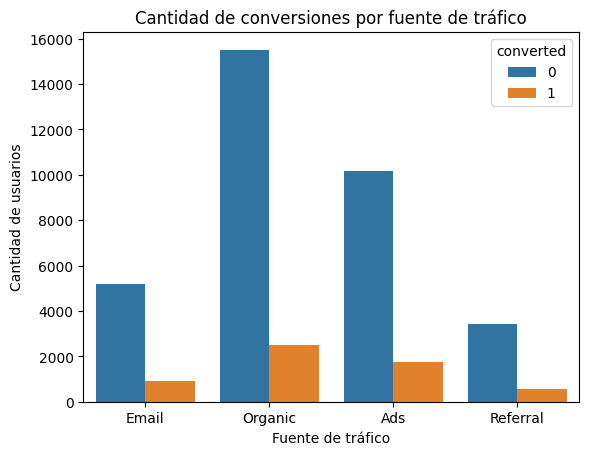

In [61]:
sns.countplot(
    data=df,
    x='traffic_source',
    hue='converted'
)

plt.title('Cantidad de conversiones por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')

plt.show()

El gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según la fuente de tráfico.

Se observa que Organic es el canal con mayor volumen de usuarios y también el que registra la mayor cantidad absoluta de conversiones. Ads ocupa el segundo lugar tanto en tráfico como en conversiones, mientras que Referral presenta el menor volumen general.

En todos los canales, la cantidad de usuarios que no convierten es considerablemente mayor que la de usuarios convertidos, aunque algunos canales parecen tener un mejor desempeño relativo en conversiones.

Estos resultados permiten identificar qué fuentes generan mayor impacto en volumen dentro del experimento analizado.

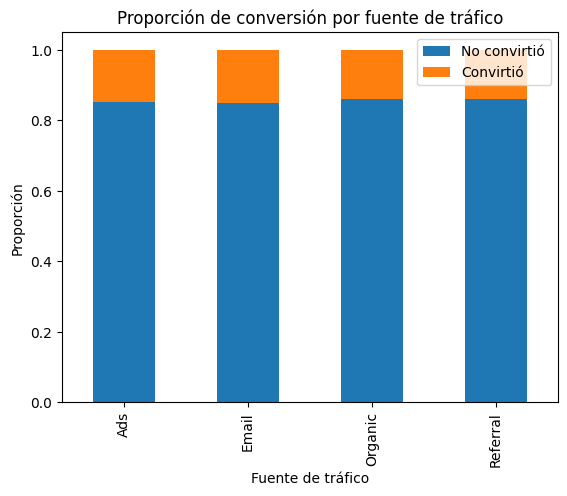

In [62]:
tabla_prop = pd.crosstab(
    df['traffic_source'],
    df['converted'],
    normalize='index'
)
tabla_prop.plot(kind='bar', stacked=True)

plt.title('Proporción de conversión por fuente de tráfico')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')

plt.legend(['No convirtió', 'Convirtió'])

plt.show()

El gráfico muestra la proporción de usuarios que convirtieron y no convirtieron para cada fuente de tráfico.

Se observa que las diferencias entre canales son relativamente pequeñas, aunque Email parece presentar una proporción de conversión ligeramente superior en comparación con Organic y Referral.

Por otro lado, Referral y Organic muestran una proporción un poco mayor de usuarios que no convierten.

Estas variaciones respaldan los resultados obtenidos en la prueba estadística, donde se identificó una relación significativa entre la fuente de tráfico y la conversión de usuarios.

### Relación entre el tipo de usuario y la conversión

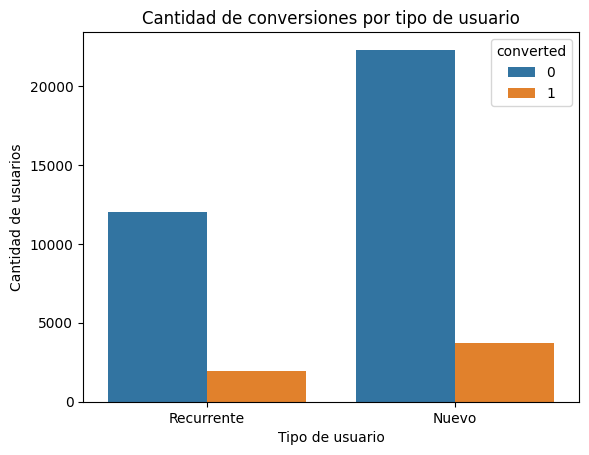

In [63]:
sns.countplot(
    data=df,
    x='user_type',
    hue='converted'
)

plt.title('Cantidad de conversiones por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')

plt.show()

Se observa que los usuarios nuevos representan el mayor volumen de usuarios dentro del experimento y también concentran la mayor cantidad absoluta de conversiones.

Sin embargo, tanto en usuarios nuevos como recurrentes, la cantidad de usuarios que no convierten sigue siendo considerablemente mayor que la de usuarios convertidos.

A nivel visual, no se perciben diferencias muy marcadas en el comportamiento de conversión entre ambos tipos de usuario.

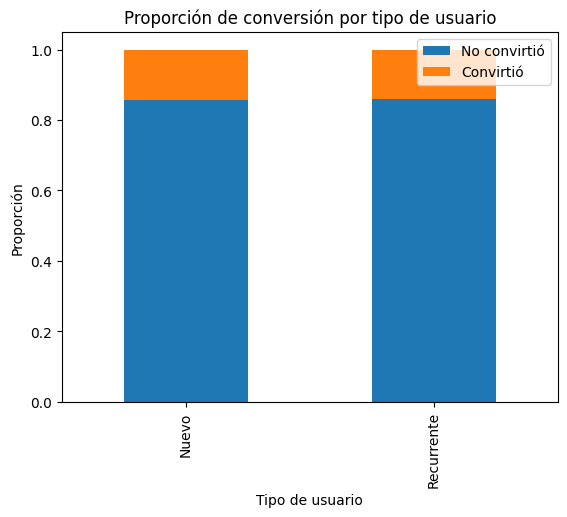

In [64]:
tabla_usuario_prop = pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
)
tabla_usuario_prop.plot(kind='bar', stacked=True)

plt.title('Proporción de conversión por tipo de usuario')
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')

plt.legend(['No convirtió', 'Convirtió'])

plt.show()

Se observa que tanto los usuarios nuevos como los recurrentes presentan proporciones de conversión muy similares, sin diferencias visuales importantes entre ambos grupos.

La mayor parte de los usuarios en ambos casos no realizó conversión, mientras que la proporción de usuarios convertidos se mantiene relativamente estable.

Estos resultados coinciden con la prueba estadística realizada previamente, donde no se encontró evidencia suficiente para afirmar que el tipo de usuario influye significativamente en la conversión.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correctos los gráficos. Haces muy bien en graficar los totales como barras separadas, pero las proporciones como barras apiladas. En ambos casos podemos visualizar la comparación de cada fuente.


</div>

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio? Los resultados del experimento A/B muestran que la versión B de la landing page obtuvo un mejor desempeño tanto en tasa de conversión como en gasto promedio por usuario convertido.
-  
- ¿Qué canales de tráfico son más efectivos para generar conversiones? En términos de adquisición de tráfico, se identificó que la fuente de tráfico sí influye en la conversión de usuarios. Canales como Organic y Ads concentraron el mayor volumen de conversiones, mientras que Email mostró una proporción de conversión competitiva en relación con su volumen total de usuarios.
- 
- ¿Existen diferencias significativas según el tipo de usuario?  Por otro lado, no se encontraron diferencias estadísticamente significativas entre usuarios nuevos y recurrentes respecto a la probabilidad de conversión. Esto indica que ambos perfiles presentan comportamientos similares dentro del experimento analizado.
- 
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
Con base en estos hallazgos, se recomienda:
- Implementar la versión B de la landing page.
- Continuar optimizando los canales con mayor volumen y mejor desempeño de conversión.
- Analizar oportunidades de mejora en fuentes de tráfico con menor efectividad relativa.
- Mantener estrategias orientadas tanto a usuarios nuevos como recurrentes, ya que no se identificaron diferencias importantes en conversión entre ambos grupos.

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La versión B presentó un gasto promedio más alto (~68.75) en comparación con la versión A (~61.09).
- La diferencia en gasto promedio entre ambas versiones fue estadísticamente significativa según la prueba t aplicada.
- **Interpretación:**
- La versión B no solo logra conversiones, sino que además genera mayor valor económico por usuario convertido, lo que representa una oportunidad para incrementar ingresos mediante la implementación de esta versión de la landing page.

<br>

**Tasa de conversión:** 
- La página B obtuvo una mayor cantidad de usuarios convertidos (3194) frente a la página A (2512).
- La prueba Z de proporciones confirmó que la diferencia en tasa de conversión entre ambas páginas es estadísticamente significativa.
- **Interpretación:**
- La versión B demuestra un mejor desempeño general en conversión, lo que indica que su diseño o experiencia de usuario resulta más efectiva para incentivar acciones de compra o conversión dentro del sitio.

---

#### 📊 **Segmentación por fuente de tráfico**
- Se identificó una relación estadísticamente significativa entre la fuente de tráfico y la conversión de usuarios.
- Organic y Ads concentraron el mayor volumen de conversiones, mientras que Email mostró una proporción de conversión competitiva en relación con su volumen de usuarios.
- **Interpretación:**
- Los resultados sugieren que la fuente de adquisición influye en el comportamiento de conversión. Algunos canales generan mayor volumen, mientras que otros pueden resultar más eficientes en términos relativos, lo que permite identificar oportunidades para optimizar la inversión en marketing digital.

 
 ---

#### 📊 **Segmentación por tipo de usuario**
- No se encontraron diferencias estadísticamente significativas entre usuarios nuevos y recurrentes respecto a la conversión.
- Las proporciones de usuarios convertidos fueron similares entre ambos grupos.
- **Interpretación:**
- El comportamiento de conversión se mantiene relativamente estable entre usuarios nuevos y recurrentes, lo que indica que la landing page funciona de forma consistente para ambos perfiles de usuario.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la versión B de la landing page, ya que presentó mejores resultados tanto en conversión como en gasto promedio.
- Priorizar y optimizar los canales de tráfico con mejor desempeño en conversiones, especialmente Organic, Ads y Email, para maximizar el retorno de inversión en marketing digital.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>


Excelentes conclusiones. Haces muy bien al incluir valores de las métricas muy importantes y resumes los principales hallazgos, buen trabajo!
    
</div>